# MIOFlow — Spatial Transcriptomics: Axolotl Brain Regeneration

This notebook walks through the **spatial MIOFlow pipeline** on Stereo-seq data from the
regenerating axolotl telencephalon:

1. Load and explore the spatial AnnData
2. Extract spatial neighbourhood features for every cell — niche expression, neighbourhood
   cell-type composition and ligand–receptor signalling
3. Train a **joint gene + spatial GAGA autoencoder** — a geometry-preserving latent space
   shaped by both what a cell expresses and where it sits
4. Train MIOFlow in that latent space to infer regeneration trajectories across days post-injury
5. Decode trajectories back to gene space to obtain gene expression trends

Standard MIOFlow (see `01_mioflow_vanilla.ipynb`) learns trajectories from expression alone. Here
each cell is also described by its tissue neighbourhood, so cells that express similar genes but
sit in different niches are pulled apart in the latent space the ODE is trained in.

> **Dataset reference:** Wei et al. (2022), *Single-cell Stereo-seq reveals induced progenitor cells
> involved in axolotl brain regeneration*, Science 377, eabp9444. Data available from the
> [ARTISTA database](https://db.cngb.org/stomics/artista/).


## 0. Installation

The spatial API (`compute_spatial_features`, `fit_joint_gaga`) is part of the development version
of MIOFlow. From the repository root, install it in editable mode:

In [1]:
# !pip install -e ..

## 1. Import Libraries

In [2]:
import os
import warnings

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import torch

from mioflow import compute_spatial_features, fit_joint_gaga, MIOFlow

np.random.seed(0)
torch.manual_seed(0)

# The merged file repeats cell IDs across sections; they are made unique after loading
warnings.filterwarnings('ignore', message='Observation names are not unique')

use_cuda = torch.cuda.is_available()
print(f'Using CUDA: {use_cuda}')

Using CUDA: False


## 2. The Axolotl Stereo-seq Data

The ARTISTA dataset profiles axolotl telencephalon sections at several days post-injury (dpi) with
Stereo-seq, which measures whole-transcriptome expression while keeping each cell's (x, y) position
in the tissue.

This tutorial uses two files:

| File | Contents |
|---|---|
| `Axolotl_batch_corrected.h5ad` | All sections merged, log-normalised, with PCA and Harmony-corrected PCA. Produced from the ARTISTA per-section files by `notebooks/axalotl-spatial/3.01.01-Axalotl-batch-correction.ipynb`. |
| `ARTISTA_LR_pairs.csv` | Ligand–receptor pair list (columns `Ligand`, `Receptor`), with gene names matching `adata.var_names`. |

In [3]:
DATA_PATH     = '../data/Axolotl/Axolotl_batch_corrected.h5ad'
LR_PAIRS_PATH = '../data/Axolotl/ARTISTA_LR_pairs.csv'

for path in (DATA_PATH, LR_PAIRS_PATH):
    if not os.path.exists(path):
        raise FileNotFoundError(
            f'{path} not found. Run notebooks/axalotl-spatial/3.01.01-Axalotl-batch-correction.ipynb '
            'first, or update the path.'
        )
print('Data files found.')

Data files found.


### 2.1 Load the Data

The merged file is ~5 GB, so we open it in **backed mode**: only metadata is read into memory until
we select the cells we need.

In [4]:
adata_full = sc.read_h5ad(DATA_PATH, backed='r')
adata_full

AnnData object with n_obs × n_vars = 170444 × 16556 backed at '../data/Axolotl/Axolotl_batch_corrected.h5ad'
    obs: 'CellID', 'spatial_leiden_e30_s8', 'Batch', 'cell_id', 'seurat_clusters', 'inj_uninj', 'D_V', 'Annotation', 'dpi'
    obsm: 'X_pca', 'X_pca_harmony', 'X_phate_gene', 'X_spatial', 'spatial'
    varm: 'pcs'
    layers: 'counts'

The AnnData object contains the following fields used in this tutorial:

**Basic Structure**
- *adata.X*: log-normalised expression, cells × genes

**Observation Metadata (`.obs`)**
- *Batch*: tissue section ID — each section is imaged separately, so spatial neighbours must come from the same section
- *dpi*: days post-injury (the time axis for MIOFlow)
- *inj_uninj*: injured or uninjured hemisphere
- *Annotation*: cell-type labels from the ARTISTA paper

**Embeddings (`.obsm`)**
- *spatial*: (x, y) coordinates of each cell within its section
- *X_pca*: gene-expression PCA (200 components)
- *X_pca_harmony*: Harmony batch-corrected PCA — the gene input to the joint embedding
- *X_phate_gene*: 2D PHATE of gene expression, for comparison

**Loadings (`.varm`)**
- *pcs*: PCA loadings, used to decode trajectories back to gene space

### 2.2 Select the Neurogenic Lineage

After injury, reactive ependymoglial cells (**reaEGC**) give rise to regeneration intermediate
progenitors (**rIPC1–4**), which become immature neurons (**IMN**) and finally mature
*nptx*⁺ excitatory neurons (**nptxEX**). We keep these cell types from the injured hemisphere.

In [5]:
CELLTYPES = ['reaEGC', 'rIPC1', 'rIPC2', 'rIPC3', 'rIPC4', 'IMN', 'nptxEX']

mask = (adata_full.obs['Annotation'].isin(CELLTYPES) & (adata_full.obs['inj_uninj'] == 'inj')).values
adata = adata_full[mask].to_memory()
adata.obs_names_make_unique()
adata.obs['Annotation'] = pd.Categorical(adata.obs['Annotation'], categories=CELLTYPES)
del adata_full

print(f'{adata.n_obs} cells × {adata.n_vars} genes from {adata.obs["Batch"].nunique()} sections\n')
pd.crosstab(adata.obs['Annotation'], adata.obs['dpi'], margins=True)

11716 cells × 16556 genes from 18 sections



dpi,2,5,10,15,20,30,60,All
Annotation,,,,,,,,
reaEGC,644,941,1348,1708,130,0,0,4771
rIPC1,0,0,0,543,0,0,0,543
rIPC2,0,0,0,404,0,0,0,404
rIPC3,0,0,0,0,362,0,0,362
rIPC4,0,0,0,0,1579,0,0,1579
IMN,0,0,283,926,533,0,0,1742
nptxEX,324,56,718,247,356,228,386,2315
All,968,997,2349,3828,2960,228,386,11716


### 2.3 Explore the Data

First the expression-only view: gene PHATE coloured by time and cell type. This is the space a
standard MIOFlow run would work in.

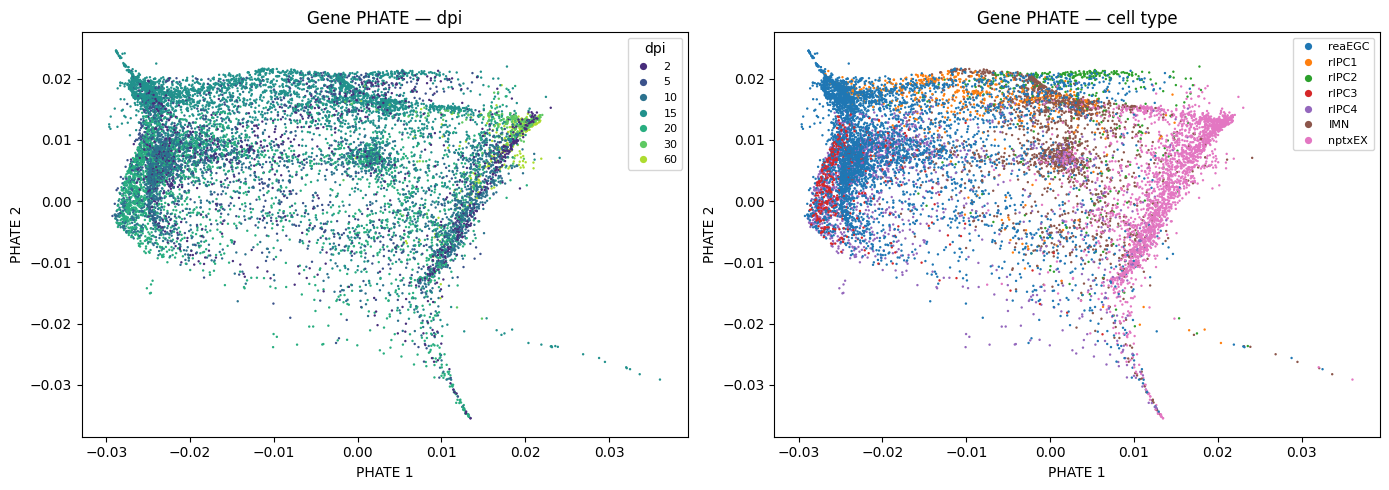

In [6]:
DPI_VALUES  = np.sort(adata.obs['dpi'].unique())
DPI_LABELS  = pd.Categorical(adata.obs['dpi'].astype(str), categories=[str(d) for d in DPI_VALUES], ordered=True)
DPI_PALETTE = dict(zip(DPI_LABELS.categories, sns.color_palette('viridis', len(DPI_VALUES))))
CT_PALETTE  = dict(zip(CELLTYPES, sns.color_palette('tab10', len(CELLTYPES))))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=adata.obsm['X_phate_gene'][:, 0], y=adata.obsm['X_phate_gene'][:, 1],
                hue=DPI_LABELS, palette=DPI_PALETTE, s=3, linewidth=0, ax=axes[0])
axes[0].set_title('Gene PHATE — dpi')
axes[0].legend(title='dpi', markerscale=3, fontsize=8)
sns.scatterplot(x=adata.obsm['X_phate_gene'][:, 0], y=adata.obsm['X_phate_gene'][:, 1],
                hue=adata.obs['Annotation'].values, palette=CT_PALETTE, s=3, linewidth=0, ax=axes[1])
axes[1].set_title('Gene PHATE — cell type')
axes[1].legend(markerscale=3, fontsize=8)
for ax in axes:
    ax.set_xlabel('PHATE 1'); ax.set_ylabel('PHATE 2')
plt.tight_layout()
plt.show()

Now the spatial view: one section per time point, cells coloured by type. Cells of the lineage
occupy distinct regions of the tissue, and that neighbourhood information is what the spatial
features capture.

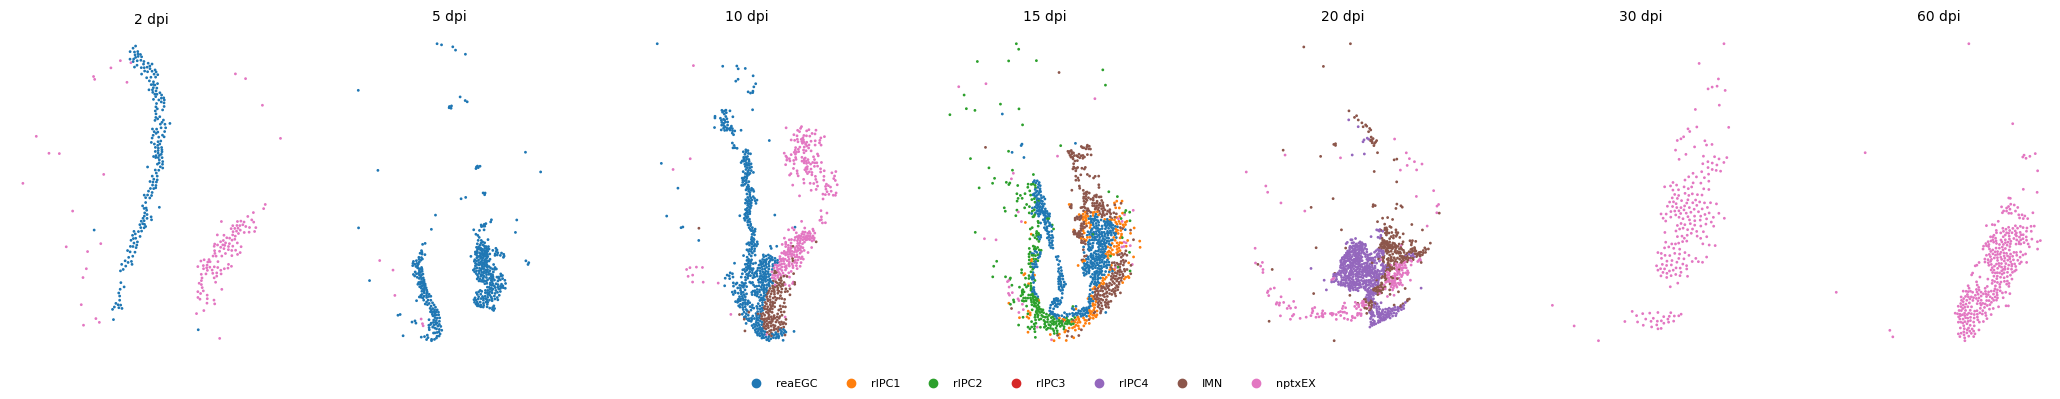

In [7]:
fig, axes = plt.subplots(1, len(DPI_VALUES), figsize=(3 * len(DPI_VALUES), 4))
for ax, dpi in zip(axes, DPI_VALUES):
    at_dpi = adata.obs['dpi'] == dpi
    section = adata.obs.loc[at_dpi, 'Batch'].value_counts().index[0]   # largest section at this dpi
    sub = adata[adata.obs['Batch'] == section]
    ax.scatter(*sub.obsm['spatial'].T, s=1, c=[CT_PALETTE[c] for c in sub.obs['Annotation']])
    ax.set_title(f'{dpi} dpi', fontsize=10)
    ax.set_aspect('equal'); ax.set_axis_off()
handles = [plt.Line2D([], [], marker='o', ls='', color=col, label=ct) for ct, col in CT_PALETTE.items()]
fig.legend(handles=handles, loc='lower center', ncol=len(CELLTYPES), fontsize=8, frameon=False)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

## 3. Spatial Neighbourhood Features

`compute_spatial_features` describes each cell by its tissue neighbourhood. It builds a spatial kNN
graph **per section** (`batch_key`) so no edges cross sections, expands it to `n_hops`, removes
edges longer than `d_max`, and aggregates three feature blocks over it:

| Block | Description | Needs |
|---|---|---|
| Niche expression | Mean expression PCs of spatial neighbours | always |
| Neighbourhood composition | Cell-type counts over neighbours and the cell itself | `celltype_key` |
| Ligand–receptor signalling | The cell's receptor expression × summed ligand expression of its neighbours, per LR pair | `lr_pairs`, `lr_expr_key` |

The blocks are z-normalised, concatenated and reduced with PCA into `adata.obsm['X_spatial']`.

### 3.1 Ligand–Receptor Expression

The LR block reads expression from a `DataFrame` in `adata.obsm` whose columns are gene names.
We use log-normalised expression for every gene in the pair list. MAGIC-imputed expression is a
common alternative that reduces dropout.

In [8]:
lr_pairs = pd.read_csv(LR_PAIRS_PATH)
lr_genes = sorted((set(lr_pairs['Ligand']) | set(lr_pairs['Receptor'])) & set(adata.var_names))

X_lr = adata[:, lr_genes].X
X_lr = X_lr.toarray() if sp.issparse(X_lr) else np.asarray(X_lr)
adata.obsm['X_lr'] = pd.DataFrame(X_lr, index=adata.obs_names, columns=lr_genes)

print(f'{len(lr_pairs)} LR pairs covering {len(lr_genes)} genes')
lr_pairs.head()

640 LR pairs covering 442 genes


,Ligand,Receptor
0,SEMA3F | AMEX60DDU001005418,PLXNA3 | AMEX60DD025642
1,SEMA3F | AMEX60DDU001005418,PLXNA1 | AMEX60DD023416
2,SEMA3F | AMEX60DDU001005418,NRP1 | AMEX60DD021789
3,SEMA3F | AMEX60DDU001005418,NRP2 | AMEX60DD055040
4,HEBP1 | AMEX60DD030506,ADRA2A | AMEX60DD053102


### 3.2 Compute the Features

| Parameter | Value | Description |
|---|---|---|
| `k` | 5 | Nearest spatial neighbours in the base graph |
| `n_hops` | 3 | Graph power: how far the neighbourhood extends |
| `d_max` | 500 | Maximum edge length, in coordinate units |
| `n_pca_niche` | 50 | Expression PCs averaged over the niche |
| `n_spatial_pca` | 50 | Output dimensions of `X_spatial` |

This step takes under a minute.

In [9]:
S = compute_spatial_features(
    adata,
    coords_key='spatial',
    k=5,
    n_hops=3,
    d_max=500,
    lr_pairs=LR_PAIRS_PATH,
    lr_expr_key='X_lr',
    celltype_key='Annotation',
    batch_key='Batch',
    n_pca_niche=50,
    n_spatial_pca=50,
    store_key='X_spatial',
)
print(f'Spatial feature matrix shape: {S.shape}')

LR features: matched 640/640 pairs against 442 expression columns


Spatial feature matrix shape: (11716, 50)


## 4. Train the Joint Gene + Spatial GAGA

`fit_joint_gaga` builds the latent space MIOFlow will be trained in:

1. Z-normalise gene PCs (`gene_key`) and spatial features (`spatial_key`) separately, so neither dominates
2. Concatenate them as `[gene, spatial_scale × spatial]` → `adata.obsm['X_joint']`
3. Run PHATE on the joint matrix
4. Train a two-phase GAGA autoencoder on it:
   - **Phase 1** — encoder learns a latent space whose distances match joint PHATE distances (decoder frozen)
   - **Phase 2** — decoder learns to reconstruct the joint features (encoder frozen)

`spatial_scale` sets how strongly spatial context shapes the manifold: `0` gives a gene-only
embedding, and larger values weight the tissue neighbourhood more.

| Parameter | Value | Description |
|---|---|---|
| `gene_key` | `'X_pca_harmony'` | Batch-corrected gene PCs |
| `spatial_scale` | 0.2 | Weight of the spatial block |
| `latent_dim` | 2 | Latent dimensions (2 for plotting) |
| `hidden_dims` | [64, 32] | Encoder / decoder hidden layers |
| `encoder_epochs`, `decoder_epochs` | 100, 100 | Epochs per training phase |

This step takes ~1–2 minutes on CPU.

In [10]:
joint_gaga = fit_joint_gaga(
    adata,
    gene_key='X_pca_harmony',
    spatial_key='X_spatial',
    spatial_scale=0.2,
    store_key='X_joint',
    latent_dim=2,
    hidden_dims=[64, 32],
    batch_size=512,
    encoder_epochs=100,
    decoder_epochs=100,
    learning_rate=1e-3,
)

Joint features: gene 200D + spatial 50D (scale=0.2) -> 250D, stored in adata.obsm['X_joint']
Computing PHATE on joint features...
Calculating PHATE...


  Running PHATE on 11716 observations and 250 variables.


  Calculating graph and diffusion operator...


    Calculating PCA...


    Calculated PCA in 0.22 seconds.


...


Epochs:  98%|█████████▊| 98/100 [00:28<00:00,  2.97it/s, train_loss=0.9317, recon=0.9317, dist=0.0145]


Epochs:  99%|█████████▉| 99/100 [00:28<00:00,  3.22it/s, train_loss=0.9317, recon=0.9317, dist=0.0145]


Epochs:  99%|█████████▉| 99/100 [00:28<00:00,  3.22it/s, train_loss=0.9316, recon=0.9316, dist=0.0145]


Epochs: 100%|██████████| 100/100 [00:28<00:00,  2.78it/s, train_loss=0.9316, recon=0.9316, dist=0.0145]


Epochs: 100%|██████████| 100/100 [00:28<00:00,  3.49it/s, train_loss=0.9316, recon=0.9316, dist=0.0145]

**Sanity check:** compare the joint latent space with the gene-only PHATE. The lineage should still
be ordered by time, now with spatial context folded in.

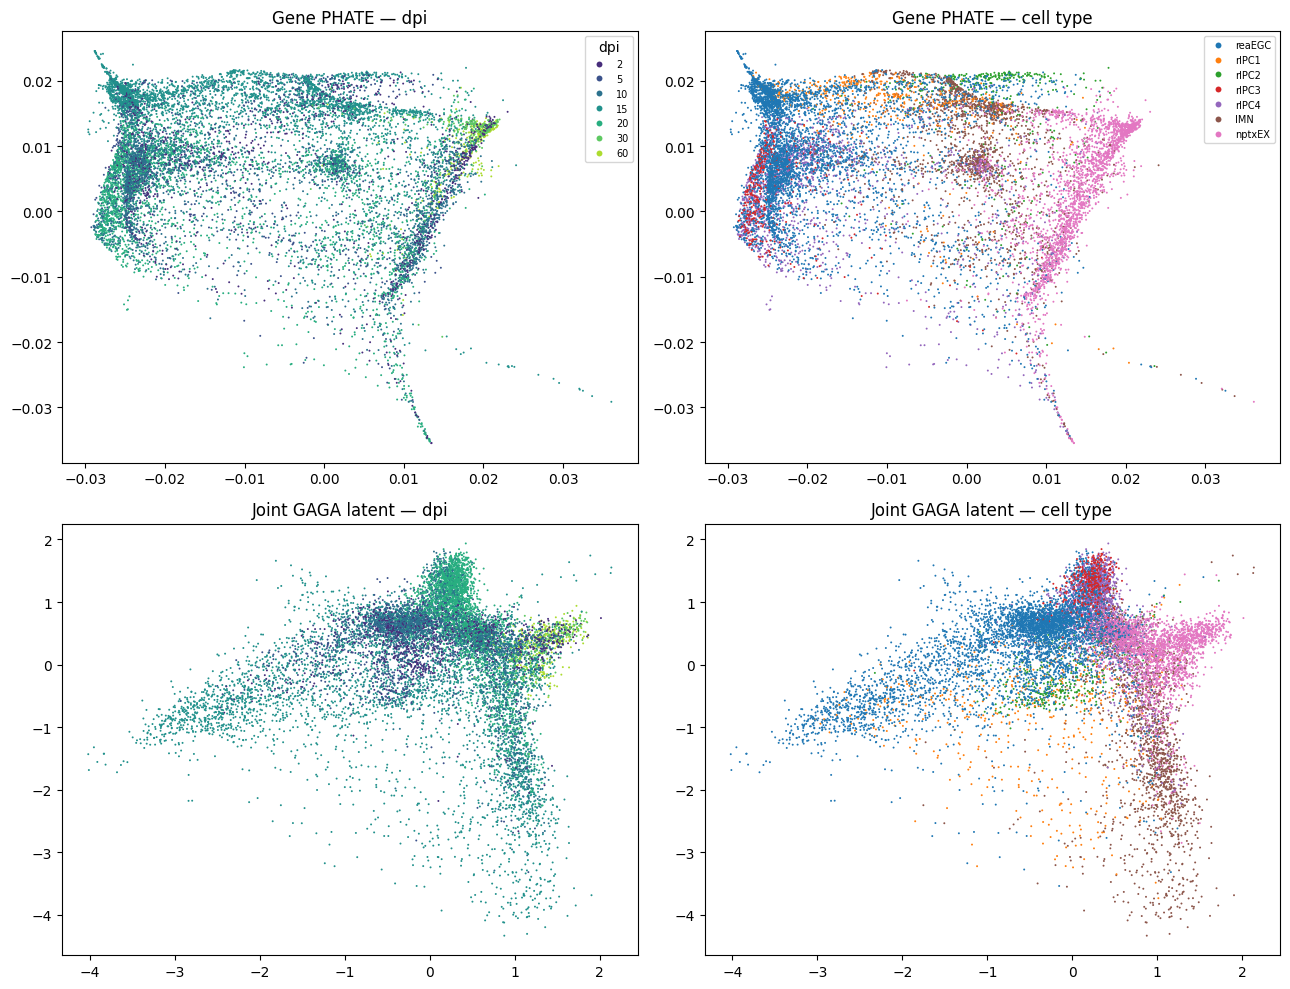

In [11]:
joint_gaga.eval()
with torch.no_grad():
    X_joint_scaled = joint_gaga.input_scaler.transform(adata.obsm['X_joint'])
    adata.obsm['X_joint_gaga'] = joint_gaga.encode(torch.tensor(X_joint_scaled, dtype=torch.float32)).numpy()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for row, (key, name) in enumerate([('X_phate_gene', 'Gene PHATE'), ('X_joint_gaga', 'Joint GAGA latent')]):
    emb = adata.obsm[key]
    sns.scatterplot(x=emb[:, 0], y=emb[:, 1], hue=DPI_LABELS, palette=DPI_PALETTE,
                    s=2, linewidth=0, ax=axes[row, 0], legend=(row == 0))
    sns.scatterplot(x=emb[:, 0], y=emb[:, 1], hue=adata.obs['Annotation'].values, palette=CT_PALETTE,
                    s=2, linewidth=0, ax=axes[row, 1], legend=(row == 0))
    axes[row, 0].set_title(f'{name} — dpi'); axes[row, 1].set_title(f'{name} — cell type')
axes[0, 0].legend(title='dpi', markerscale=3, fontsize=7)
axes[0, 1].legend(markerscale=3, fontsize=7)
plt.tight_layout()
plt.show()

## 5. Configure MIOFlow

Pass the joint model as `gaga_model` and point `gaga_input_key` at `'X_joint'`. MIOFlow applies
`joint_gaga.input_scaler` and the encoder itself, then trains the Neural ODE in the joint latent space.

| Parameter | Value | Description |
|---|---|---|
| `obs_time_key` | `'dpi'` | Time label for each cell |
| `n_epochs` | 200 | Training epochs |
| `hidden_dim` | 64 | ODE network width |
| `lambda_ot`, `lambda_density`, `lambda_energy` | 1.0, 0.1, 0.01 | Loss weights |
| `sample_size` | 100 | Cells sampled per time point per batch |
| `n_trajectories` | 100 | Trajectories integrated after training |
| `n_bins` | 100 | Time steps per trajectory |


> **Time axis:** MIOFlow ranks the `dpi` values, so the seven time points (2, 5, 10, 15, 20, 30, 60 dpi)
> become evenly spaced steps 0 … 6 rather than being proportional to days.

In [12]:
mf = MIOFlow(
    adata,
    gaga_model=joint_gaga,
    gaga_input_key='X_joint',
    obs_time_key='dpi',
    debug_level='info',
    hidden_dim=64,
    use_cuda=use_cuda,
    momentum_beta=0.0,
    # Training
    n_epochs=200,
    # Loss
    use_density_loss=True,
    lambda_ot=1.0,
    lambda_density=0.1,
    lambda_energy=0.01,
    energy_time_steps=20,
    # Data / output
    sample_size=100,
    n_trajectories=100,
    n_bins=100,
    exp_dir='.',
)

2026-09-29 16:50:07,304 - MIOFlow - INFO - MIOFlow initialised | 11716 cells, 16556 genes | device=cpu


## 6. Train

`fit()` trains the Neural ODE end-to-end with the optimal-transport loss, then integrates
`n_trajectories` cells from the first time point forward.

In [13]:
mf.fit()
print(mf)

2026-09-29 16:50:07,318 - MIOFlow - INFO - ODEFunc: input_dim=2, hidden_dim=64


2026-09-29 16:50:07,318 - MIOFlow - INFO - Global training: 200 epochs



Training (global):   0%|          | 0/200 [00:00<?, ?it/s]


Training (global):   0%|          | 1/200 [00:01<05:26,  1.64s/it]


Training (global):   1%|          | 2/200 [00:02<04:44,  1.44s/it]

...


Training (global): 100%|██████████| 200/200 [03:32<00:00,  1.15s/it]


Training (global): 100%|██████████| 200/200 [03:32<00:00,  1.06s/it]

2026-09-29 16:53:40,197 - MIOFlow - INFO - Trajectories generated: shape=(100, 100, 2)


2026-09-29 16:53:40,198 - MIOFlow - INFO - MIOFlow fitting completed.


MIOFlow(n_obs=11716, gaga=Autoencoder, n_epochs=200, trajectories=(100, 100, 2), status=fitted)


## 7. Training Losses

The total loss should fall and then level off. `mf.losses` holds per-epoch values of each component.

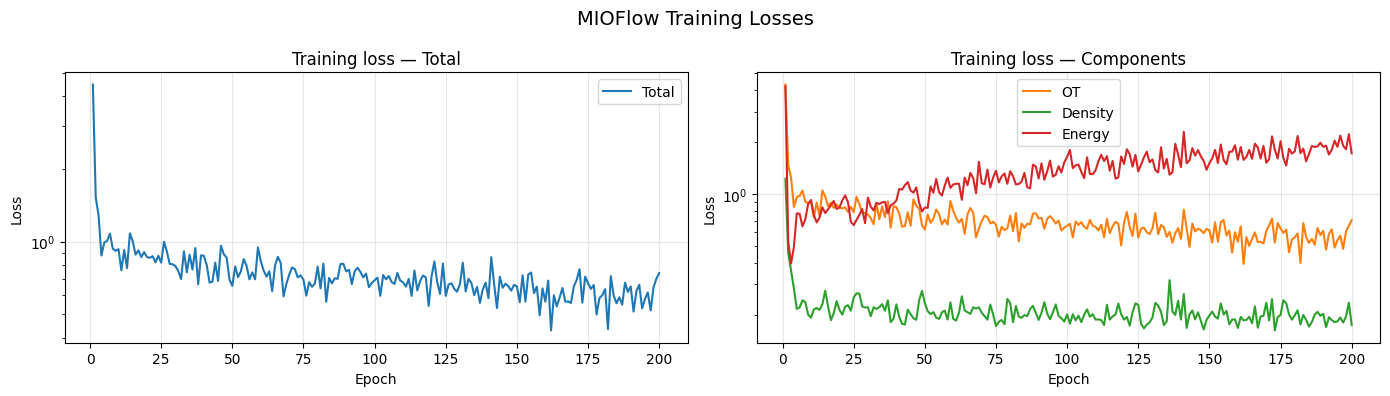

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
epochs = mf.losses['epoch']

axes[0].plot(epochs, mf.losses['total_loss'], label='Total', color='tab:blue')
axes[0].set_title('Training loss — Total')

axes[1].plot(epochs, mf.losses['ot_loss'],      label='OT',      color='tab:orange')
axes[1].plot(epochs, mf.losses['density_loss'], label='Density', color='tab:green')
axes[1].plot(epochs, mf.losses['energy_loss'],  label='Energy',  color='tab:red')
axes[1].set_title('Training loss — Components')

for ax in axes:
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_yscale('log')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('MIOFlow Training Losses', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Visualise Trajectories

`mf.trajectories` has shape **`(n_bins, n_trajectories, latent_dim)`** and is in the same coordinates
as `mf.embedding` (the encoded cells), so the two can be plotted together directly.

Trajectory shape (n_bins, n_trajectories, latent_dim): (100, 100, 2)


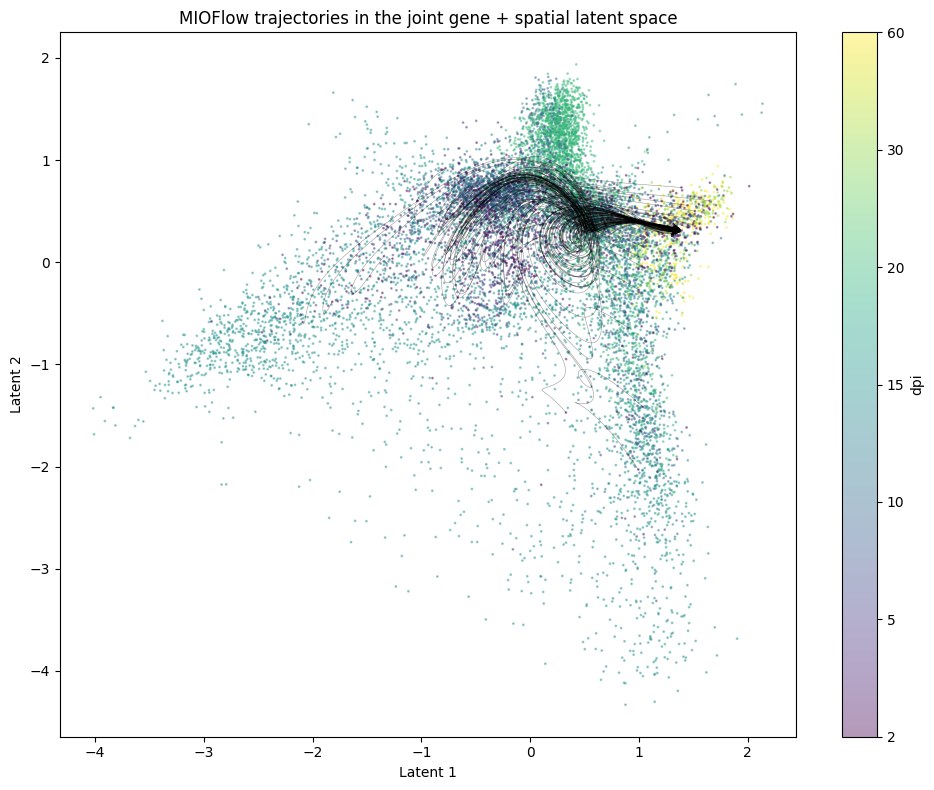

In [15]:
print('Trajectory shape (n_bins, n_trajectories, latent_dim):', mf.trajectories.shape)

fig, ax = plt.subplots(figsize=(10, 8))
p = ax.scatter(mf.embedding[:, 0], mf.embedding[:, 1], c=mf._time_labels, cmap='viridis', s=1, alpha=0.4)
cbar = plt.colorbar(p, ax=ax, ticks=range(len(DPI_VALUES)))
cbar.set_ticklabels(DPI_VALUES); cbar.set_label('dpi')

for traj in mf.trajectories.transpose(1, 0, 2):   # (n_bins, latent_dim) per trajectory
    ax.plot(traj[:, 0], traj[:, 1], color='black', lw=0.4, alpha=0.4)
    ax.annotate('', xy=traj[-1, :2], xytext=traj[-2, :2],
                arrowprops=dict(arrowstyle='->', color='black', lw=0.4, mutation_scale=10))

ax.set_xlabel('Latent 1'); ax.set_ylabel('Latent 2')
ax.set_title('MIOFlow trajectories in the joint gene + spatial latent space')
plt.tight_layout()
plt.show()

## 9. Decode Trajectories to Gene Space

`decode_to_gene_space()` maps trajectories through the chain:

**joint latent → GAGA decoder → joint features → gene block (inverse scaler) → PCA loadings → gene space**

For a joint model the spatial block of the decoded features is discarded. Because the gene input was
Harmony-corrected PCs, which share the PCA basis in `adata.varm['pcs']`, decoded values are
batch-corrected approximations of log expression.

Returns shape **`(n_bins, n_trajectories, n_genes)`**.

In [16]:
trajectories_gene_space = mf.decode_to_gene_space(pcs_key='pcs')
print('Gene-space trajectory shape (n_bins, n_trajectories, n_genes):', trajectories_gene_space.shape)

Gene-space trajectory shape (n_bins, n_trajectories, n_genes): (100, 100, 16556)


## 10. Gene Expression Trends

Axolotl gene names have the form `SYMBOL | AMEX-ID`. The helpers below look genes up by symbol and
collect the observed mean expression at each time point for comparison with the decoded trends.

In [17]:
def find_gene(symbol):
    # Return the var_name whose symbol part is `symbol` (first match)
    hits = [g for g in adata.var_names if g.split(' | ')[0] == symbol]
    if not hits:
        raise KeyError(f"No gene with symbol '{symbol}'")
    return hits[0]

def short_name(var_name):
    # Symbol for plot titles; falls back to the AMEX ID for unannotated genes
    symbol, _, gene_id = var_name.partition(' | ')
    return gene_id if symbol == 'nan' else symbol

# Decoded trajectories run over time ranks 0 … n_timepoints-1
x_time = np.linspace(0, len(DPI_VALUES) - 1, trajectories_gene_space.shape[0])

def observed_mean(gene_mask):
    X = adata[:, gene_mask].X
    X = X.toarray() if sp.issparse(X) else np.asarray(X)
    return np.stack([X[mf._time_labels == t].mean(axis=0) for t in range(len(DPI_VALUES))])

def set_dpi_axis(ax):
    ax.set_xticks(range(len(DPI_VALUES))); ax.set_xticklabels(DPI_VALUES); ax.set_xlabel('dpi')

### 10.1 Top Highly-Variable Genes

We select the 25 most highly variable genes in the lineage and plot their decoded mean expression
(± std over trajectories) against the observed mean at each time point.

Stereo-seq is sparse, and dispersion-based HVG selection favours genes detected in only a handful of
cells, so we first restrict to genes detected in at least 10% of cells.

In [18]:
detected = np.asarray((adata.X > 0).mean(axis=0)).ravel() >= 0.10
print(f'{detected.sum()} genes detected in ≥10% of cells')

adata_expressed = adata[:, detected].copy()
sc.pp.highly_variable_genes(adata_expressed, n_top_genes=25)
example_genes     = adata_expressed.var_names[adata_expressed.var['highly_variable']]
del adata_expressed
example_gene_mask = adata.var_names.isin(example_genes)
print('Top 25 highly variable genes:\n', [short_name(g) for g in example_genes])

4592 genes detected in ≥10% of cells


Top 25 highly variable genes:
 ['AMEX60DD002299', 'NEFM', 'AMEX60DD008090', 'PSME1', 'AB205_0156120[nr]|KRT19[hs]', 'ECM1', 'NRAD[nr]|RRAD[hs]', 'CRABP2', 'AMEX60DD016339', 'CDH13', 'GNG5', 'AMEX60DD021526', 'LOC115094431[nr]', 'DR999_PMT04687[nr]|CTSF[hs]', 'OTUB1', 'HB-B[nr]|HBD[hs]', 'MMP9[nr]|MMP2[hs]', 'TENM2', 'HMOX1', 'APBB2', 'INTS11', 'STT3A', 'LOC111165522[nr]|NTM[hs]', 'AMEX60DD054004', 'LOC100555387[nr]|IGFBP5[hs]']


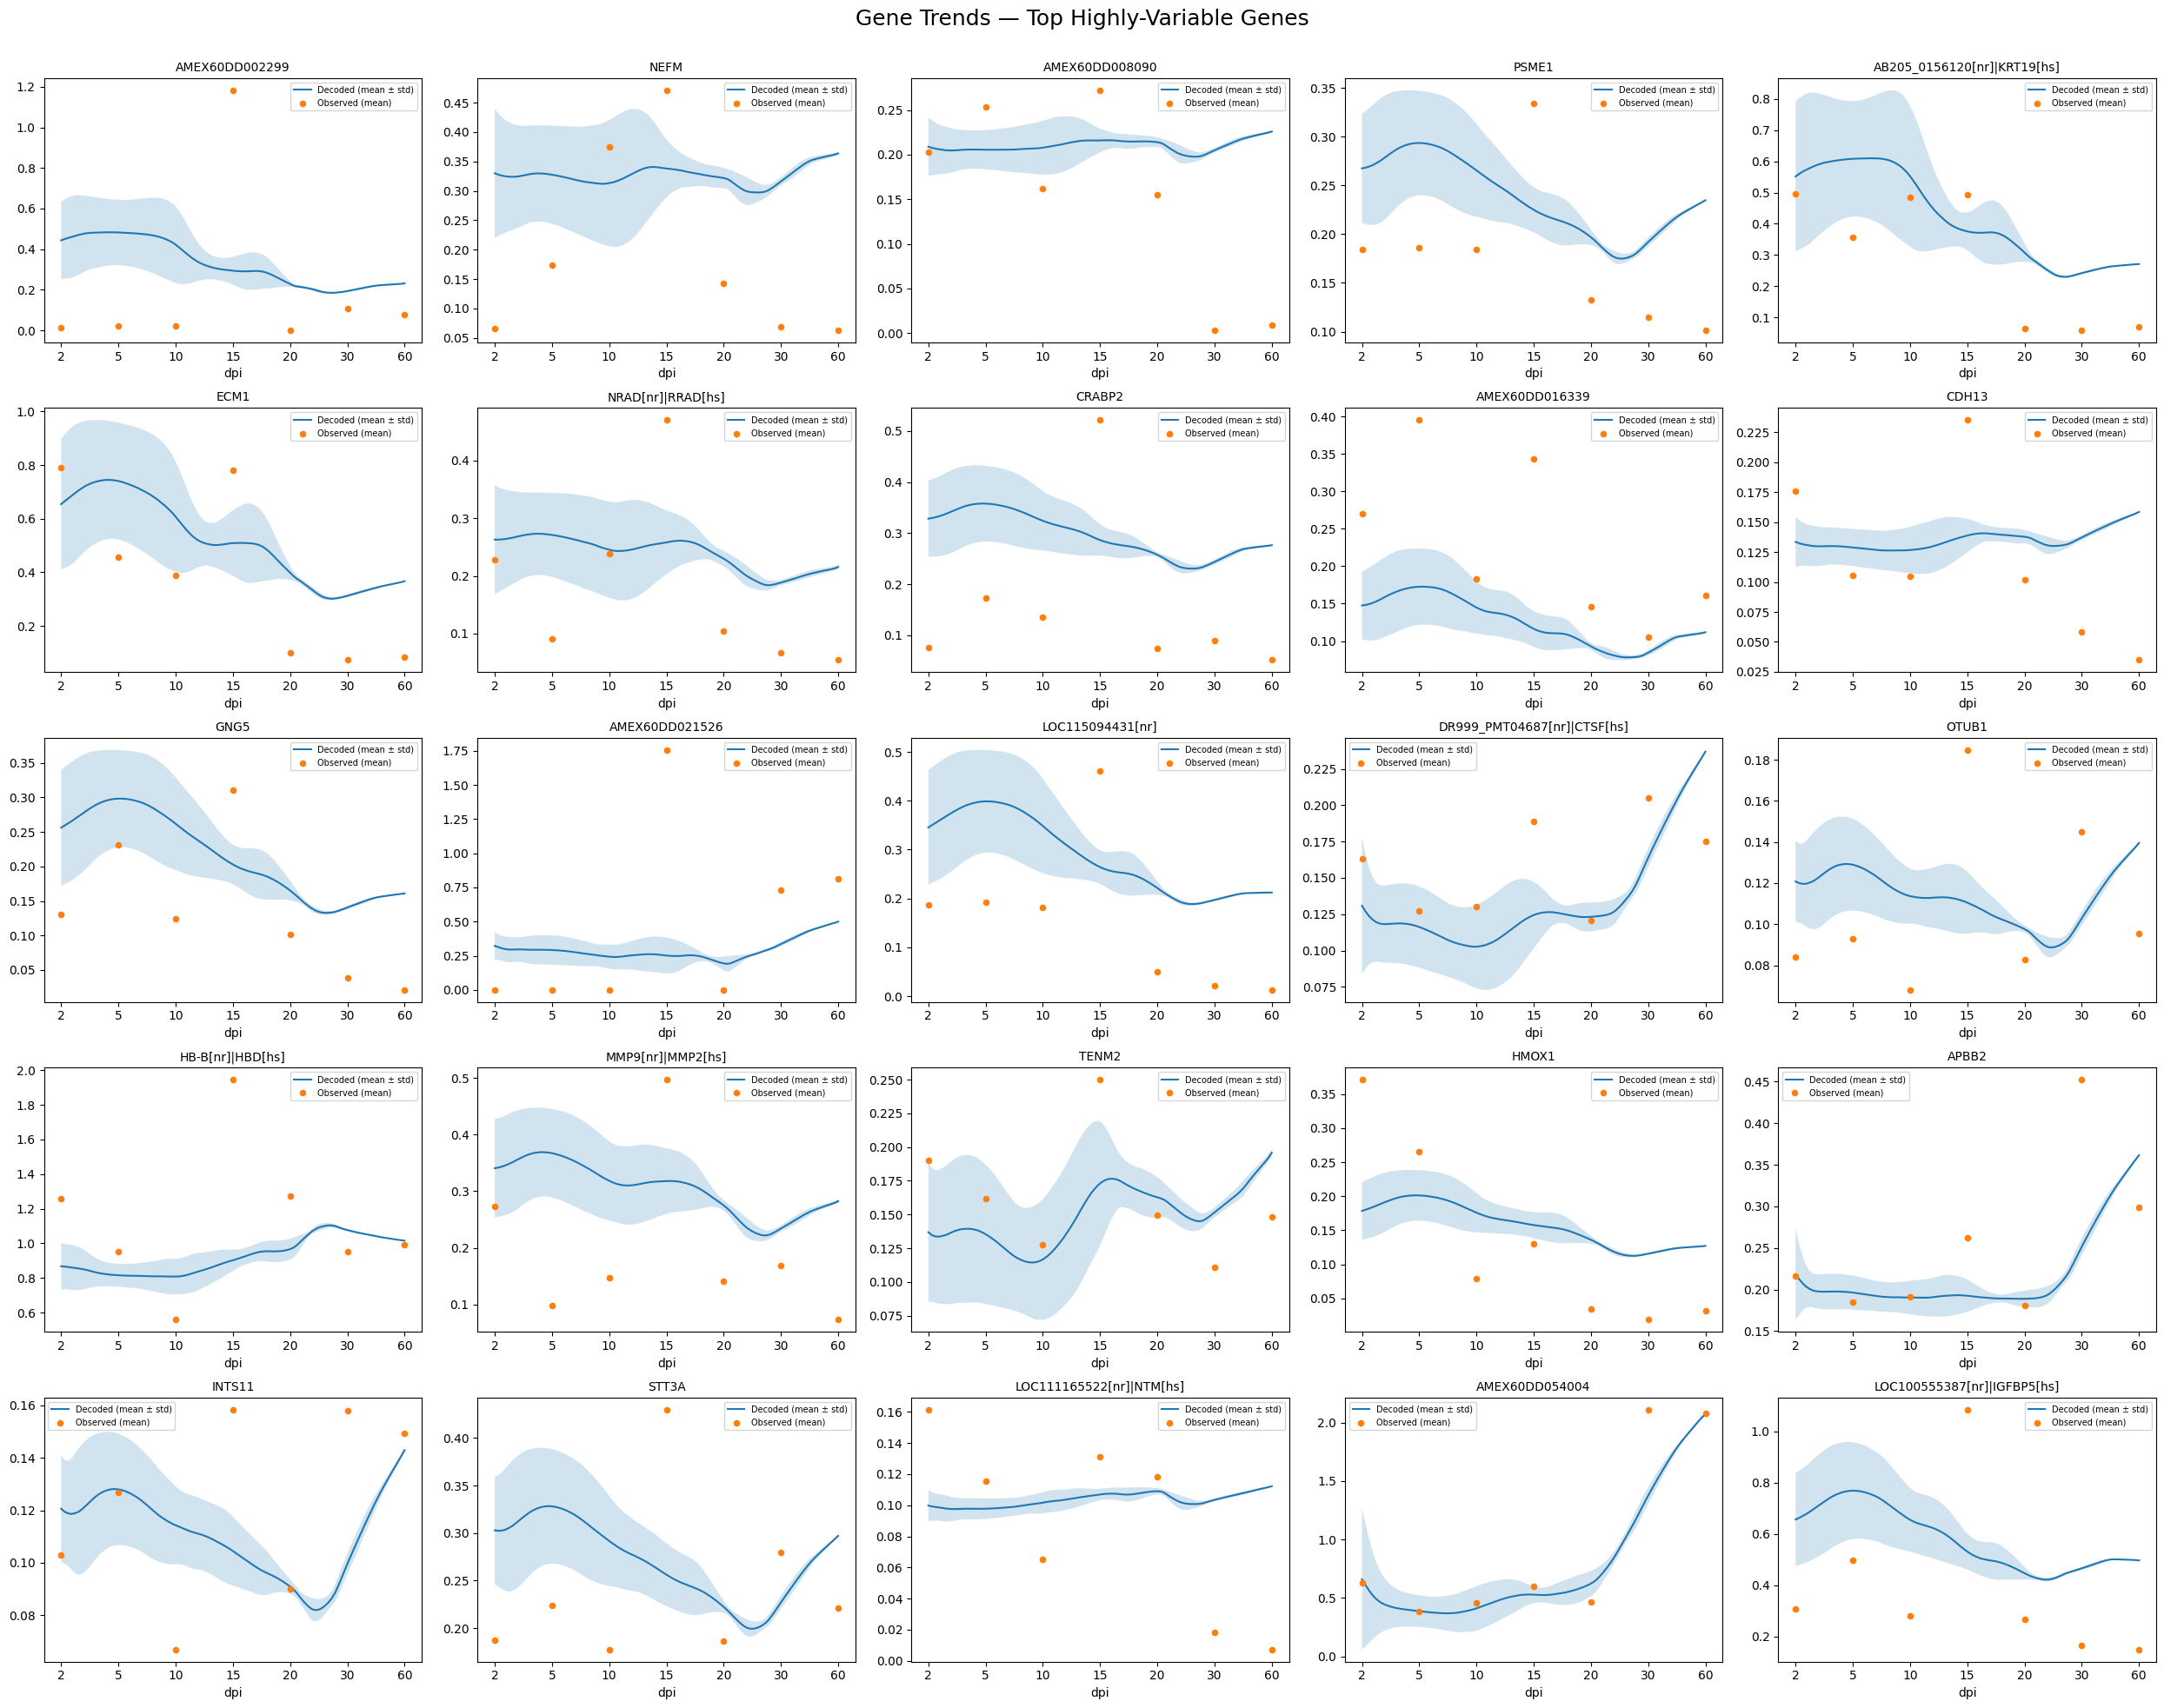

In [19]:
decoded_hvg      = trajectories_gene_space[:, :, example_gene_mask]   # (n_bins, n_traj, n_hvg)
decoded_hvg_mean = decoded_hvg.mean(axis=1)                            # (n_bins, n_hvg)
decoded_hvg_std  = decoded_hvg.std(axis=1)
observed_hvg     = observed_mean(example_gene_mask)                    # (n_timepoints, n_hvg)

n_genes = len(example_genes)
n_cols  = 5
n_rows  = int(np.ceil(n_genes / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, gene in enumerate(example_genes):
    ax = axes[i]
    ax.plot(x_time, decoded_hvg_mean[:, i], label='Decoded (mean ± std)')
    ax.fill_between(x_time, decoded_hvg_mean[:, i] - decoded_hvg_std[:, i],
                    decoded_hvg_mean[:, i] + decoded_hvg_std[:, i], alpha=0.2)
    ax.scatter(range(len(DPI_VALUES)), observed_hvg[:, i], s=20, color='tab:orange',
               label='Observed (mean)', zorder=3)
    ax.set_title(short_name(gene), fontsize=10)
    set_dpi_axis(ax)
    ax.legend(fontsize=7)

for i in range(n_genes, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Gene Trends — Top Highly-Variable Genes', fontsize=18)
plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()

### 10.2 Single Gene of Interest

Replace `interest_gene` with any gene symbol. *NPTX1* marks the mature nptxEX neurons at the end of
the lineage; try *VIM* or *SOX2* for the progenitor end.

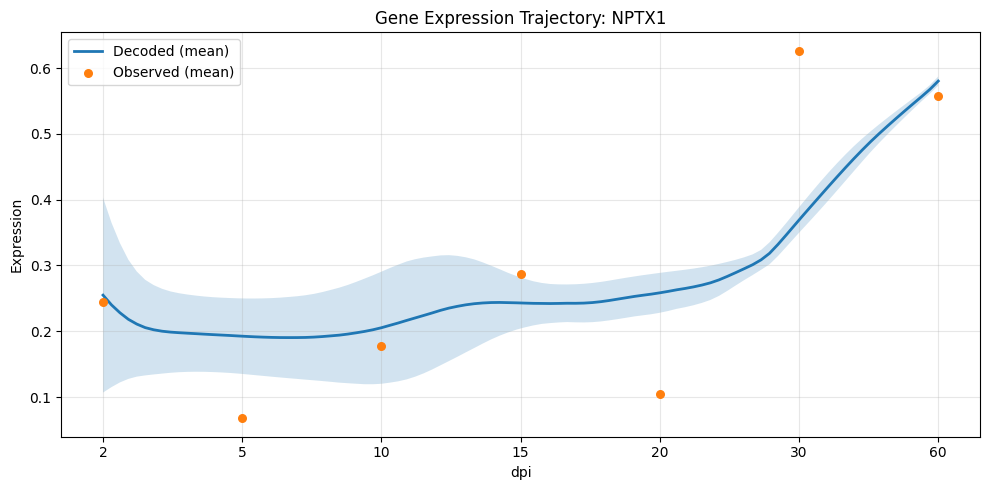

In [20]:
interest_gene = 'NPTX1'   # change this to any gene symbol

gene_mask    = adata.var_names == find_gene(interest_gene)
decoded_gene = trajectories_gene_space[:, :, gene_mask][:, :, 0]   # (n_bins, n_traj)
gene_mean    = decoded_gene.mean(axis=1)
gene_std     = decoded_gene.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_time, gene_mean, linewidth=2, label='Decoded (mean)')
ax.fill_between(x_time, gene_mean - gene_std, gene_mean + gene_std, alpha=0.2)
ax.scatter(range(len(DPI_VALUES)), observed_mean(gene_mask)[:, 0], s=30, color='tab:orange',
           label='Observed (mean)', zorder=3)
set_dpi_axis(ax)
ax.set_ylabel('Expression')
ax.set_title(f'Gene Expression Trajectory: {interest_gene}')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Next Steps

- **`spatial_scale`** — rerun section 4 with `0` for a gene-only baseline, or raise it to weight tissue context more
- **Feature blocks** — drop `lr_pairs` or `celltype_key` in section 3 to see what each block contributes
- **Neighbourhood size** — `k`, `n_hops` and `d_max` control how local the niche is
- **`latent_dim`** — higher dimensions preserve more structure; plot the first two for visualisation
- **Your own data** — any AnnData with spatial coordinates, a time label and gene PCs works; set
  `batch_key` whenever it contains more than one section